# 03 · Extra: hypervolume, early stopping & model selection

Optional extras for when the basics are in place: what the early-stopping indicator
measures, how early stopping is switched on, and how GPU plugs into scikit-learn
cross-validation, grid search and pipelines.

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from foresight_gpu import GPURegressor
from foresight_gpu.models import MLPModel
from foresight_gpu.scoring import make_gpu_scorer
from foresight_gpu.utils import plot_history, plot_hypervolume

rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, size=(500, 2))
y = np.sin(2 * np.pi * X[:, 0]) + 0.3 * X[:, 1] + 0.25 * rng.standard_normal(500)

cut = 300                                   # chronological 80/20 split
X_tr, y_tr, X_va, y_va = X[:cut], y[:cut], X[cut:], y[cut:]
print('train', X_tr.shape, '| validation', X_va.shape)

train (300, 2) | validation (200, 2)


## 1 · The hypervolume indicator

GPU keeps a population of models, each with a non-exceedance level $\eta$ and a loss. Front 0
is the lowest loss reached at each $\eta$. The **hypervolume** is the area between that
staircase and a ceiling $R$ (the reference point), reported normalised as
$hv = 1 - D/R \in [0, 1]$ (higher is better). Here $D$ integrates the loss over the covered
$\eta$ range and charges $R$ for every uncovered stretch. It therefore rises both when the
loss drops and when the front spreads across the exceedance axis. By default $R$ is
adaptive; this demo fixes it.

Each cell of the staircase takes the higher of its two particles' losses. The two cells
beside the lowest-loss particle are split at their midpoint, so that particle holds the
staircase down between the midpoints. Every front model therefore counts, the best one
included.

hv = 0.8117 | coverage = 1.00 | front size = 59


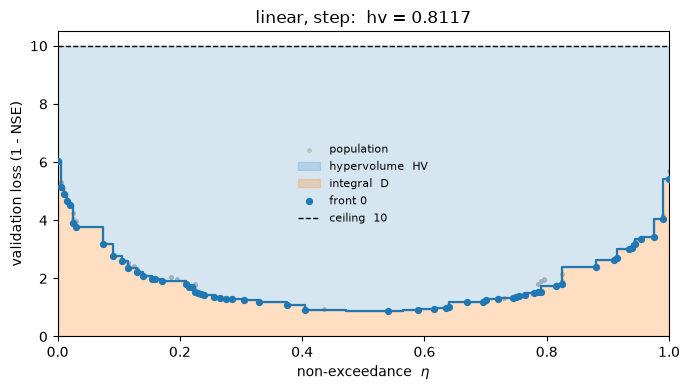

In [8]:
# a fixed hv_reference so the shaded areas are comparable across runs (default is adaptive).
demo = GPURegressor(population=100, metric='nse', n_iter=40,
                    hv_reference=10, random_state=0).fit(X_tr, y_tr)
eta, loss, front = demo.ensemble_.front_objectives(X_va, y_va)
space_ = 'linear' #linear or log10
interpolation_ = 'step' #linear or step

ax = plot_hypervolume(eta, loss, demo.hv_reference_, front=front, space=space_, interpolation=interpolation_,
                      ylabel='validation loss (1 - NSE)')
ax.figure.set_size_inches(7, 4)
ax.figure.tight_layout()

parts = demo.ensemble_.score_hypervolume(X_va, y_va, details=True, space=space_, interpolation=interpolation_)
print(f"hv = {parts['hv']:.4f} | coverage = {parts['coverage']:.2f} | front size = {parts['n_front']}")

## 2 · Early stopping

There is no `early_stopping` flag: it runs whenever validation data exists, monitoring the
validation hypervolume every `check_every` generations and restoring the best ensemble after
`n_iter_no_change` checks without improvement.

| call | early stopping |
|---|---|
| `fit(X, y)` | off — full `n_iter`, whole record trains |
| `GPURegressor(validation_fraction=0.2).fit(X, y)` | on, internal chronological tail |
| `fit(X, y, X_val=Xv, y_val=yv)` | on, your split; **all** of `X` trains |

Two records come out of the fit:

- `history_` holds the hypervolume at every check. Early stopping reads it.
- `diagnostics_` holds reliability $\alpha$, resolution $\pi$ and CRPS every
  `diagnostics_every` generations, for training and validation.

Both are lists of dicts keyed by `iteration`. `plot_history` draws them in one figure, with
the retained model marked as a star.

early stopping ran: True
stopped at iteration 35 | best iteration 14


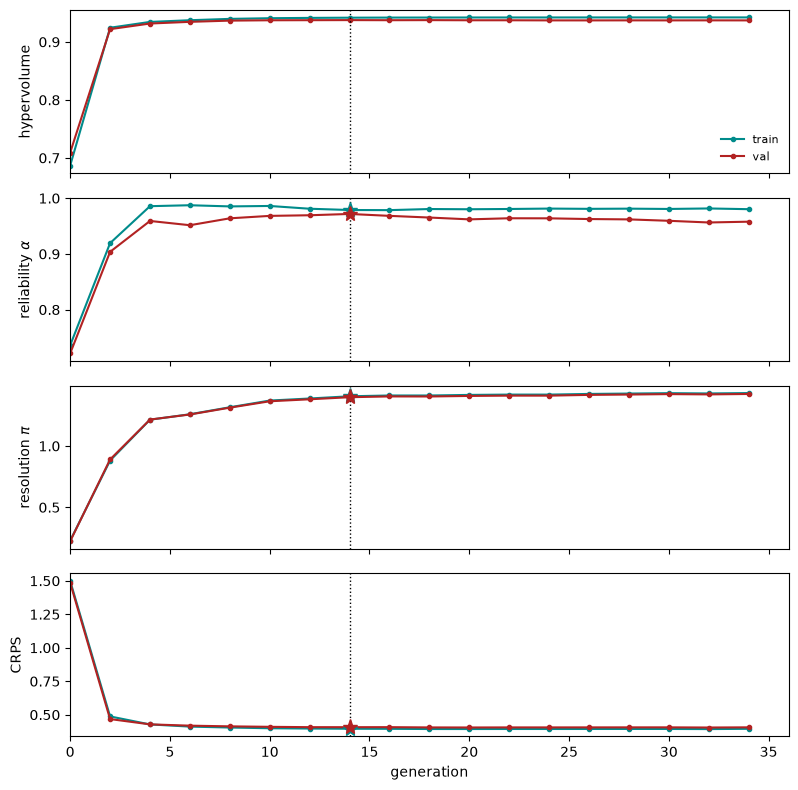

In [9]:
gpu_es = GPURegressor(population=300, n_iter=400, n_iter_no_change=10, check_every=2,
                      diagnostics_every=2, random_state=0).fit(X_tr, y_tr, X_val=X_va, y_val=y_va)
print('early stopping ran:', gpu_es.early_stopping_)
print('stopped at iteration', gpu_es.n_iter_, '| best iteration', gpu_es.best_iteration_)

axes = plot_history(gpu_es.history_, gpu_es.diagnostics_, gpu_es.best_iteration_)
axes[0].figure.set_size_inches(8, 8)
axes[0].set_xlim(0, gpu_es.n_iter_ + 1)
axes[0].figure.tight_layout()


The same problem without validation data runs the full `n_iter`. Scoring both on the held-out
block shows what stopping bought (`score_hypervolume` reads the ensemble `predict` uses).

In [10]:
gpu_full = GPURegressor(population=300, n_iter=gpu_es.n_iter_ * 2,
                        random_state=0).fit(X_tr, y_tr)
print('early stopping ran:', gpu_full.early_stopping_, '| generations:', gpu_full.n_iter_)
print(f'with early stopping:    hv = {gpu_es.score_hypervolume(X_va, y_va):.4f}')
print(f'without early stopping: hv = {gpu_full.score_hypervolume(X_va, y_va):.4f}')

early stopping ran: False | generations: 70
with early stopping:    hv = 0.9376
without early stopping: hv = 0.9367


## 3 · Time-series cross-validation on a probabilistic score

`make_gpu_scorer` builds scorers that use the probabilistic output (the default sklearn
scorer only sees `predict`).

> Cross-validation does not slice `X_val`: passed through `fit`, every fold gets the same
> block. Inside CV use `validation_fraction` so each fold carves its own tail.

In [11]:
est = GPURegressor(population=200, n_iter=40, random_state=0)
for name in ('reliability', 'hypervolume'):
    scores = cross_val_score(est, X, y, cv=TimeSeriesSplit(4), scoring=make_gpu_scorer(name))
    print(f'{name:12s} per fold:', np.round(scores, 3))

reliability  per fold: [0.866 0.908 0.959 0.927]
hypervolume  per fold: [0.946 0.926 0.956 0.955]


## 4 · Grid search over model and regularisation parameters

The forward model is a nested parameter, so `model__*` is searchable.

In [12]:
search = GridSearchCV(
    GPURegressor(model=MLPModel(), population=150, n_iter=30, random_state=0),
    {'model__n_hidden': [4, 8], 'model__reg_lambda': [0.0, 1e-3]},
    cv=TimeSeriesSplit(3), scoring=make_gpu_scorer('hypervolume'))
search.fit(X, y)
print('best params:', search.best_params_)

best params: {'model__n_hidden': 8, 'model__reg_lambda': 0.0}
